###**DIP Practical-9**

**Name:** Yesha Pandya

**Enrollment Number:** 23BT04175

**Div:** 1 **Batch:** C

#### **Objective:**

Develop an application to subtract background and foreground using Otzu's algorithm. Also, count the number of objects in the given image.

**Import libraries and image**

In [9]:
#import libraries needed
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

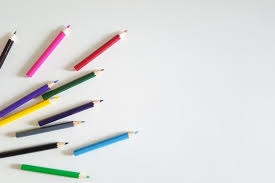

In [10]:
#load and show original image
img=cv2.imread('pencils.jpeg')
cv2_imshow(img)

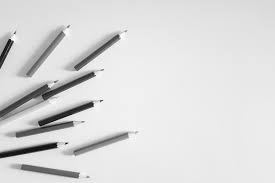

In [11]:
#convert to grayscale
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

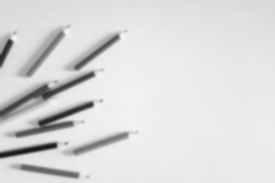

In [12]:
# apply Gausian blur to remove high-frequency noise
# this strictly improves the bimodal distribution for Otsu's method.
blur=cv2.GaussianBlur(gray,(5,5),0)
cv2_imshow(blur)

#### **Otsu's Thresholding for Background/Foreground Separation**
Thresholding is a non-linear operation that converts a grayscale image into a binary image. Standard thresholding requires manually choosing a threshold value.

Otsu's method, however, automates this process by analyzing the image histogram. Otsu's algorithm assumes the image contains two classes of pixels (foreground and background), forming a bimodal histogram. It iterates through all possible threshold values (0-255) and calculates the optimal threshold that minimizes the intra-class variance (the spread of pixels within the background and foreground classes) and maximizes the inter-class variance.

The intra-class variance is given by:

$$\sigma_w^2(t) = \omega_0(t)\sigma_0^2(t) + \omega_1(t)\sigma_1^2(t)$$

Where weights $\omega_0$ and $\omega_1$ are the probabilities of the two classes separated by a threshold $t$, and $\sigma_0^2$ and $\sigma_1^2$ are the variances of these classes.


Step 1c: Applying Otsu's Thresholding
Otsu's algorithm calculated the optimal threshold value as: 171.0


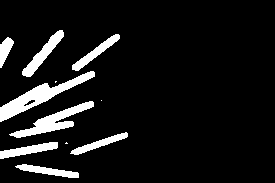

In [13]:
print("\nStep 1c: Applying Otsu's Thresholding")
# we use cv2.THRESH_BINARY_INV so objects become white (255) and background becomes black (0).
# This is crucial because OpenCV's contour detection finds white objects on a black background.
# If your image has a dark background and light objects, simply use cv2.THRESH_BINARY.
optimal_threshold, binary_mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

print(f"Otsu's algorithm calculated the optimal threshold value as: {optimal_threshold}")
cv2_imshow(binary_mask)

#### **Object Counting via Contour Detection**

Once the image is effectively binarized (foreground is white, background is black), we can count the objects by finding continuous blobs of white pixels. In Digital Image Processing, this is done using Contour Tracing or Connected Component Analysis.

A contour is a curve joining all the continuous points along a boundary that have the same color or intensity. OpenCV's findContours algorithm scans the binary image topologically to retrieve these boundaries. We use the `RETR_EXTERNAL` retrieval mode to ensure we only count the outermost outlines of the objects, ignoring any holes or internal markings inside them.

Detecting contours to count objects..

Drawing Contours on Original Image


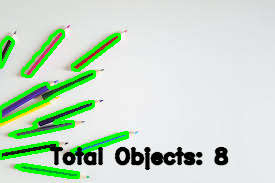

RESULT: Successfully detected and counted 8 objects.


In [17]:
# Find Contours and Count Objects

if img is not None:
    print("Detecting contours to count objects..")

    # find contours on the binary mask
    # RETR_EXTERNAL fetches only the extreme outer contours
    # CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments to save memory
    contours, hierarchy = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Count the number of valid objects (Optional: Filter out noise based on area)
    min_object_area = 50 # Minimum pixel area to be considered a valid object (removes tiny noise dots)
    valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_object_area]

    object_count = len(valid_contours)

    print("\nDrawing Contours on Original Image")
    # create a copy of the original image to draw on
    output_img = img.copy()

    # draw all valid contours (-1) in green (0, 255, 0) with a thickness of 2
    cv2.drawContours(output_img, valid_contours, -1, (0, 255, 0), 2)

    # put text on the image displaying the count
    text = f'Total Objects: {object_count}'
    # Get image dimensions to place text at bottom-left
    img_height, img_width, _ = output_img.shape
    cv2.putText(output_img, text, (50, img_height - 20), cv2.FONT_HERSHEY_DUPLEX,
                0.7, (0, 0, 0), 2, cv2.LINE_AA)

    cv2_imshow(output_img)

    print(f"RESULT: Successfully detected and counted {object_count} objects.")